In [1]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import Lasso, lasso_path, LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
REPO_DIR = Path("..")
DATA_DIR = REPO_DIR / "Data"

X_train = pd.read_csv(DATA_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(DATA_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(DATA_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv", index_col=0).squeeze("columns")


In [3]:
lasso_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42, max_iter=10000))
])


param_grid = {
    'lasso__alpha': np.logspace(-4,1,50)
    }
search = GridSearchCV(
    lasso_pipe, 
    param_grid, 
    cv=5, 
    scoring='neg_root_mean_squared_error'
    )

search.fit(X_train, y_train)

y_train_pred = search.predict(X_train)
y_test_pred = search.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Best alpha: {search.best_params_['lasso__alpha']}")
print(f"Best CV RMSE: {-search.best_score_}")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R^2:", train_r2)
print("Test R^2:", test_r2)

Best alpha: 0.00032374575428176434
Best CV RMSE: 0.13534051065018826
Train RMSE: 0.12763118054314654
Test RMSE: 0.13649345405472468
Train R^2: 0.701421879703748
Test R^2: 0.6489240426508722


In [4]:
print("y_train min:", y_train.min())
print("y_train max:", y_train.max())
print("y_train mean:", y_train.mean())
print("y_train std:", y_train.std())

print("y_test min:", y_test.min())
print("y_test max:", y_test.max())
print("y_test mean:", y_test.mean())
print("y_test std:", y_test.std())

response_range = y_train.max() - y_train.min()
rmse = 0.1367

print("Response range:", response_range)
print("RMSE as % of range:", rmse / response_range)

y_train min: 0.0
y_train max: 1.0
y_train mean: 0.24037013801756585
y_train std: 0.23364907560845655
y_test min: 0.0
y_test max: 1.0
y_test mean: 0.22844611528822056
y_test std: 0.23065145119506336
Response range: 1.0
RMSE as % of range: 0.1367


**Note**:
>Per [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html),
>Alpha in this case is not the elastic net, L1 ratio. It represents the overall penalty strength, represented by lambda in class and our textbook. 


In [5]:
best_lasso = search.best_estimator_.named_steps['lasso']

coef = pd.Series(
    best_lasso.coef_,
    index=X_train.columns
)
print(f"Total Number of Feataures: {len(coef)}")

selected_features = coef[coef != 0].sort_values(key=np.abs, ascending=False)

print("Number of selected features:", len(selected_features))
print(selected_features.head(20))

Total Number of Feataures: 100
Number of selected features: 77
MedRent             0.058426
racepctblack        0.056444
PctPersDenseHous    0.054778
whitePerCap        -0.046775
PctKids2Par        -0.041085
agePct12t29        -0.036642
RentLowQ           -0.035959
OwnOccLowQuart     -0.034785
OwnOccHiQuart       0.032230
pctWInvInc         -0.031910
HousVacant          0.031838
PctEmploy           0.031555
PctPopUnderPov     -0.026699
PctFam2Par         -0.026539
PctWorkMom         -0.025508
PersPerOccupHous    0.023705
PctIlleg            0.021553
MalePctDivorce      0.020398
PctLargHouseFam    -0.020316
NumStreet           0.020151
dtype: float64


**Results**:
LASSO achieved a morderate predictive performance on the test set ($R^2 = 0.649$), but the optimal penalty was small, so the model retained 72 out of 100 predictors. This suggests that crime rates in this dataset are associated with a broad set of correlated community characteristics rather than a very small subset of variables. Additionally, the lower alpha allows closer data fitting, meaning there is a risk of overfitting. 

The test RMSE of 0.1385 means that predicted values of ViolentCrimesPerPop differ from observed values by about 0.139 on average in the original response scale. This suggests the LASSO model captures the overall trend in violent crime rates, but still produces noticeable prediction error for individual communities, especially at moderate to high crime levels.

The gap between train and test $R^2$ is small, so there is some overfitting, but not a significant amount. This means the model is generalizing reasonbly well. 

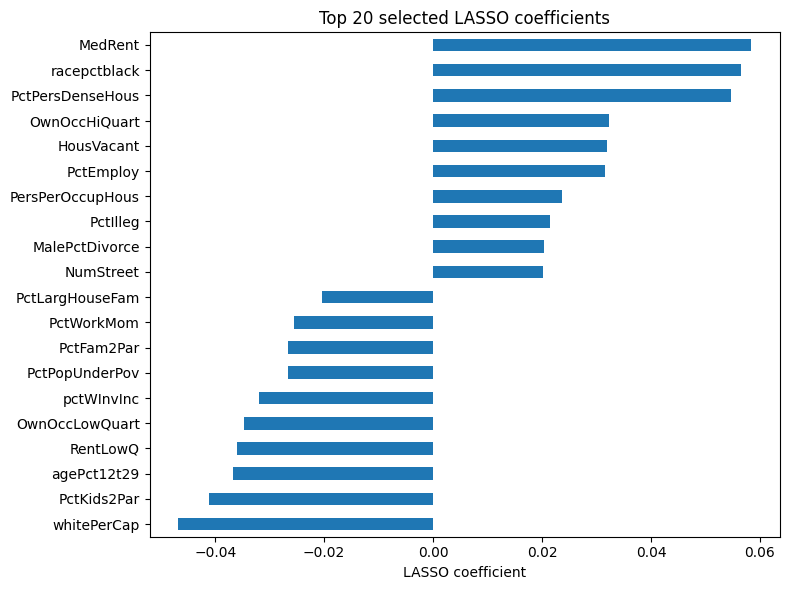

In [6]:
top_coef = selected_features.head(20).sort_values()

plt.figure(figsize=(8,6))
top_coef.plot(kind='barh')
plt.xlabel("LASSO coefficient")
plt.title("Top 20 selected LASSO coefficients")
plt.tight_layout()
plt.show()

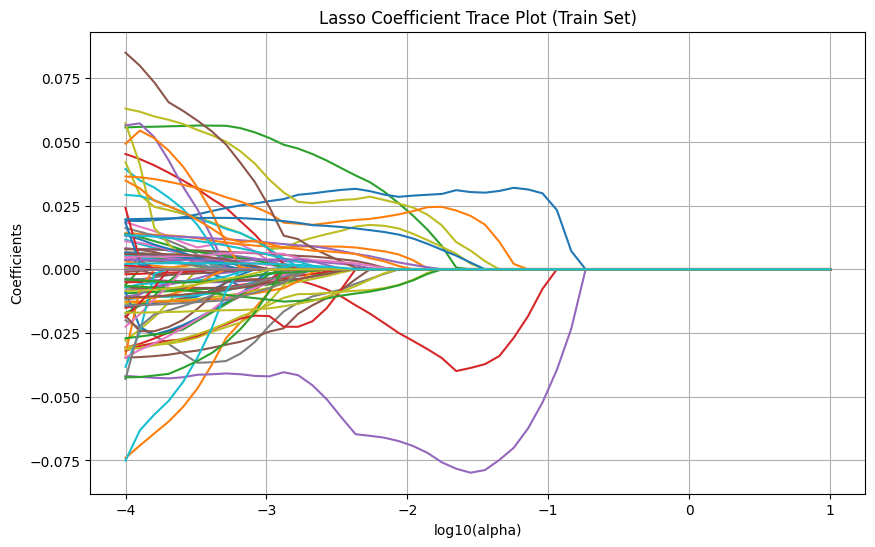

In [7]:
preprocessor = lasso_pipe[:-1]

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

alphas = np.logspace(-4,1,50)
alphas, coefs, _ = lasso_path(X_train_scaled, y_train, alphas = alphas, max_iter = 10000)

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), coefs.T)
plt.xlabel('log10(alpha)')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficient Trace Plot (Train Set)')
plt.axis('tight')
plt.grid(True)
plt.show()

* Many predictors have small but nonzero coefficients. That means when the penalty is weak, the model keeps a lot of variables. 

* As alpha increases, most lines collapse toward zero fairly quickly, suggesting many predictors are not strong enough to survive regularization. 

* Have lots of weak predictors and only a few with consistent signals
 
* Lasso is helping by simplifying the model

### LASSO Residual Plots

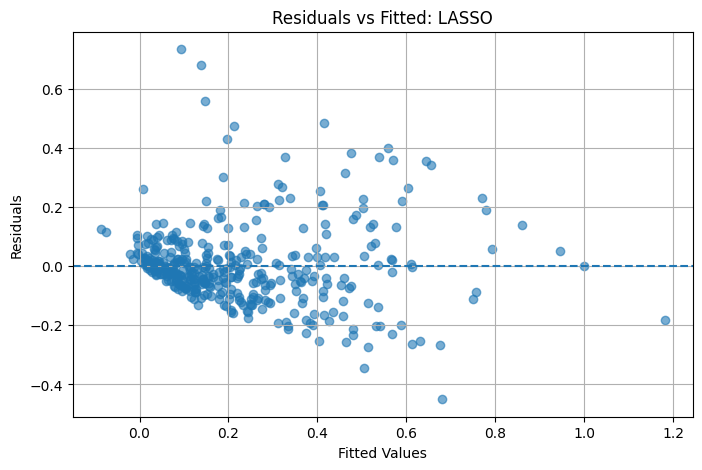

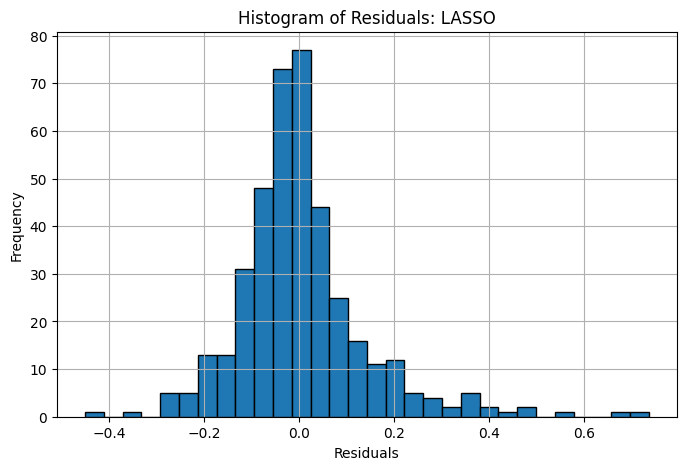

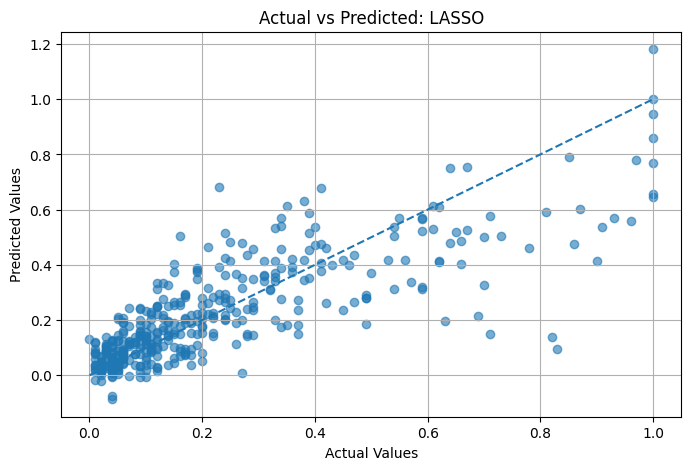

In [8]:
residuals = y_test - y_test_pred

# Residuals vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: LASSO")
plt.grid(True)
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals: LASSO")
plt.grid(True)
plt.show()

# Actual vs Predicted 
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted: LASSO")
plt.grid(True)
plt.show()

The diagnostic plots suggest that the LASSO model captures the overall relationship in the data reasonably well, as shown by the positive alignment in the actual-versus-predicted plot and residuals centered around zero. However, the residuals-versus-fitted plot shows increasing spread at larger fitted values, indicating heteroskedasticity and less consistent performance for higher predicted violent crime rates. The residual histogram is roughly centered and approximately bell-shaped, but with some skew and a few outliers, suggesting that while the model is not strongly biased overall, it does not fully capture all variation in the response. Overall, the diagnostics support LASSO as a useful linear baseline, but they also suggest room for improvement in modeling more complex patterns.


## OLS Comparison

In [9]:
ols_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

param_grid = {
    'regressor__fit_intercept': [True, False],
    'regressor__copy_X': [True,False]
}

grid_search = GridSearchCV(
    estimator=ols_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_search.fit(X_train, y_train)

y_train_pred = grid_search.predict(X_train)
y_test_pred = grid_search.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Best CV RMSE: {-search.best_score_}")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R^2:", train_r2)
print("Test R^2:", test_r2)


Best CV RMSE: 0.13534051065018826
Train RMSE: 0.12705785670308756
Test RMSE: 0.13855081681212486
Train R^2: 0.7040983021268548
Test R^2: 0.6382607600828487
